In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X_train = pd.read_csv(r"training\X_train_scaled.csv")
Y_train = pd.read_csv(r"training\Y_train.csv")

In [98]:
def compute_predictions(inputs, weights):
    predictions = np.sum(weights * inputs, axis = 1)
    return predictions

In [99]:
def MSE_Calculation(predictions, actuals):
    actuals.reshape(predictions.shape[0],)
    summed_squared_errors = (predictions - actuals) ** 2
    MSE = summed_squared_errors.mean()
    return MSE

In [100]:
def compute_gradient(input: list[list], predictions: list, actuals: list):
    errors = predictions - actuals
    return (input.T @ errors) / len(actuals)
    

In [101]:
def update_weights(weights: list, gradient: list, learning_rate: float):
    return weights - (gradient * learning_rate)

In [104]:
def train_loop(input, weights, actuals, epochs, learning_rate):
    actuals = actuals.reshape(input.shape[0], )
    MSE_rate = []
    for i in range(1, epochs + 1):
        predictions = compute_predictions(input, weights)
        MSE = MSE_Calculation(predictions, actuals)
        gradient = compute_gradient(input, predictions, actuals)
        weights = update_weights(weights, gradient, learning_rate)
    
        if i % 100 == 0:
            print("Epoch: ", i)
            print("MSE: ", MSE)
            print("Updated Weights: ", weights)
            MSE_rate.append(MSE)
    
    return MSE_rate, weights

In [109]:
def test_loop(input, weights, actuals):
    actuals = actuals.reshape(input.shape[0], )
    predictions = compute_predictions(input, weights)
    MSE = MSE_Calculation(predictions, actuals)
        
    return MSE

Epoch:  100
MSE:  5.762015124911803
Updated Weights:  [0.92026304 0.75658416 0.13492598 0.19530142 0.52201457 0.2930866
 0.84848541 0.88668867]
Epoch:  200
MSE:  5.271933437922382
Updated Weights:  [ 0.93630194  0.55033823 -0.04736735  0.07812646  0.28951789  0.0504776
  0.75016127  0.78034514]
Epoch:  300
MSE:  5.152493637205919
Updated Weights:  [ 0.94702034  0.43001642 -0.11773057  0.08060087  0.1755418  -0.02948679
  0.65568743  0.68315197]
Epoch:  400
MSE:  5.095445641811799
Updated Weights:  [ 0.95153232  0.36237878 -0.16299206  0.10724657  0.11756139 -0.05394548
  0.56458514  0.591155  ]
Epoch:  500
MSE:  5.05530772743738
Updated Weights:  [ 0.95378952  0.32266049 -0.19863846  0.13855326  0.08667182 -0.06015736
  0.47799904  0.50379829]
Epoch:  600
MSE:  5.022651860118962
Updated Weights:  [ 0.95538004  0.29742929 -0.22858298  0.16943443  0.06925191 -0.06075387
  0.39631647  0.42122494]
Epoch:  700
MSE:  4.994880440606519
Updated Weights:  [ 0.95667777  0.27984391 -0.25436192  0

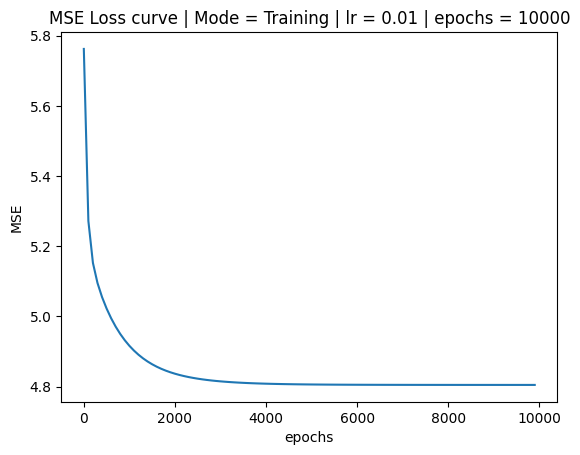

Test MSE: 4.805121892660496


In [110]:
learning_rate = 0.01
epochs = 10000
epoch_rate = np.arange(0, epochs, 100)
weights = np.ones(8)
MSE_rate, weights = train_loop(X_train.to_numpy(), weights, Y_train.to_numpy(), epochs, learning_rate)
    
plt.plot(epoch_rate, MSE_rate)
plt.ylabel("MSE")
plt.xlabel("epochs")
plt.title(f"MSE Loss curve | Mode = Training | lr = {learning_rate} | epochs = {epochs}")
plt.savefig("plots/Train_MSE_loss_curve.png")
plt.show()

MSE = test_loop(X_train.to_numpy(), weights, Y_train.to_numpy())
print(f"Test MSE: {MSE}")


In [111]:
RMSE = MSE ** 0.5
print(f"RMSE: {RMSE}")

RMSE: 2.192058825091265
